<a href="https://colab.research.google.com/github/BJut7021/TH_DeepLearning/blob/main/Lab4_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

2.1. Nạp thư viện

In [47]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten
from keras.models import Sequential
from keras import Input

import matplotlib.pyplot as plt

2.2. Đọc dữ liệu MNIST

In [48]:
mnist_train = '/content/sample_data/mnist_train_small.csv'
mnist_test = '/content/sample_data/mnist_test.csv'
df_train = pd.read_csv(mnist_train)
df_test = pd.read_csv(mnist_test)

print(df_train.shape)
X_train = df_train.iloc[:,1:].values
y_train = df_train.iloc[:,0].values
X_test = df_test.iloc[:,1:].values
y_test = df_test.iloc[:,0].values

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(19999, 785)
(19999, 784) (19999,) (9999, 784) (9999,)


2.2. Đọc dữ liệu MNIST

In [49]:
num_classes = 10
input_shape = (28,28,1)
X_train = X_train.astype('float32')/255
X_test = X_test.astype('float32')/255
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
print(X_train.shape)
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)
print(X_test.shape)

print('Number of classes:', len(np.unique(y_train)))
print(' Classes:', np.unique(y_train))
print(y_train[:5])

(19999, 28, 28, 1)
(9999, 28, 28, 1)
Number of classes: 10
 Classes: [0 1 2 3 4 5 6 7 8 9]
[5 7 9 5 2]


2.3. Trực quan hóa 10 ảnh đầu tiên


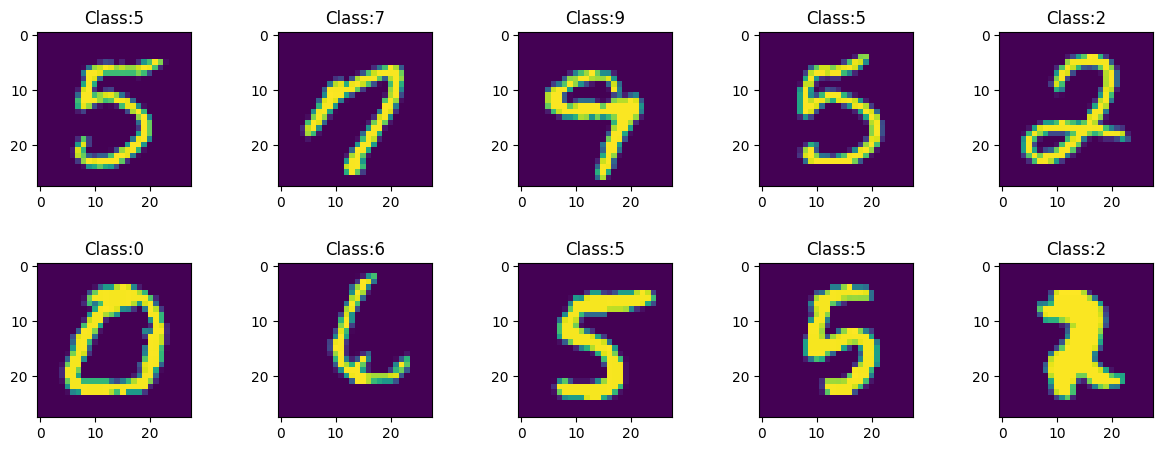

In [50]:
fig, axrs = plt.subplots(nrows=2, ncols=5, figsize=(15,5))
ax = axrs.ravel()
for i in range(10):
  ax[i].imshow(X_train[i].reshape(28,28))
  ax[i].title.set_text('Class:'+str(y_train[i]))
plt.subplots_adjust(hspace=0.5)
plt.show()

2.4. Chuyển giá trị nhãn thành one-hot encoding

In [51]:
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

2.5. Xây dựng mô hình CNN

In [52]:
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

2.6. Huấn luyện mô hình CNN

In [53]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_fit = model.fit(X_train, y_train, batch_size=128, epochs=15, validation_split=0.1, verbose=1)

Epoch 1/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step - accuracy: 0.8395 - loss: 0.5871 - val_accuracy: 0.9435 - val_loss: 0.2114
Epoch 2/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - accuracy: 0.9571 - loss: 0.1491 - val_accuracy: 0.9590 - val_loss: 0.1408
Epoch 3/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - accuracy: 0.9697 - loss: 0.1014 - val_accuracy: 0.9640 - val_loss: 0.1110
Epoch 4/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 10s 54ms/step - accuracy: 0.9746 - loss: 0.0811 - val_accuracy: 0.9710 - val_loss: 0.0902
Epoch 5/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.9799 - loss: 0.0646 - val_accuracy: 0.9720 - val_loss: 0.0947
Epoch 6/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 11s 53ms/step - accuracy: 0.9826 - loss: 0.0559 - val_accuracy: 0.9765 - val_loss: 0.0864
Epoch 7/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - accuracy: 0.9858 - loss: 0.0457 - val_accuracy: 0.9765 - val_loss: 0.0828
Epoch 8/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 10s 54ms/step - accuracy: 0.9879 - loss: 0.0387 - va

2.7. Đánh giá mô hình CNN

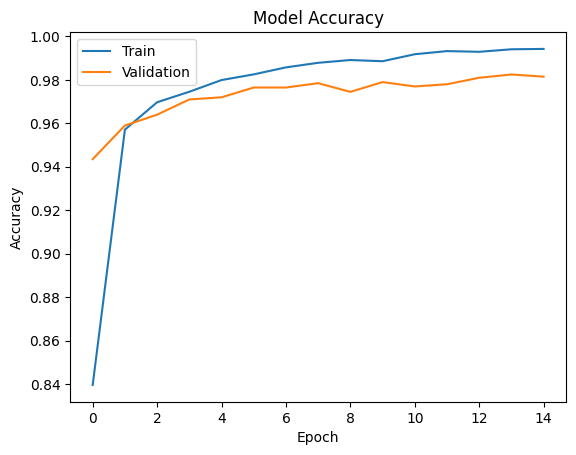

In [57]:
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

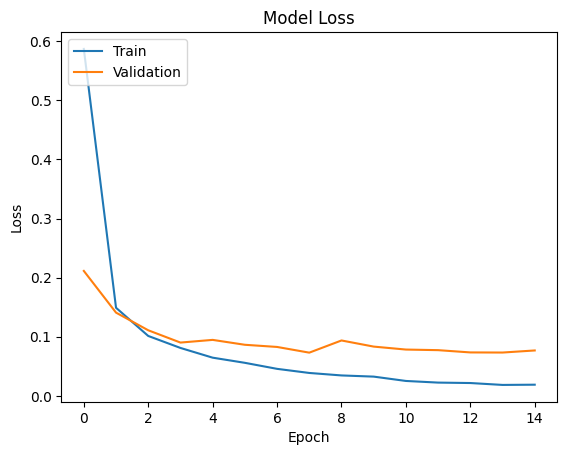

In [58]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

2.8. Đánh giá mô hình CNN thử nghiệm trên tập test

In [56]:
score = model.evaluate(X_test, y_test_corrected, verbose=2)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

313/313 - 2s - 5ms/step - accuracy: 0.9848 - loss: 0.0538
Test loss: 0.05381638556718826
Test accuracy: 0.9847984910011292


2.9. Dự báo nhãn cho ảnh sử dụng CNN


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
[[3.0156792e-07 4.2525685e-06 9.9999535e-01 8.8146719e-11 6.0996086e-19
  8.3109645e-15 1.2838673e-08 7.0637800e-18 2.9142494e-10 2.5617166e-21]]
2 2


<function matplotlib.pyplot.show(close=None, block=None)>

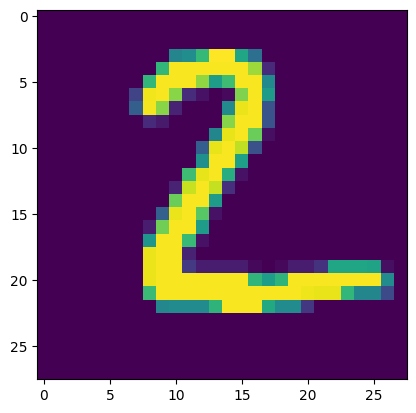

In [59]:
predict = model.predict(X_test[:1])
print(predict)
print(np.argmax(predict),np.argmax(y_test[0]))
plt.imshow(X_test[:1].reshape(28,28))
plt.show

2.10. Lưu tham số mô hình CNN

In [66]:
model.save_weights('cnn.weights.h5')

2.11. Nạp lại mô hình và tham số

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
[[3.3450129e-07 9.9990213e-01 9.8162182e-06 4.9125173e-08 7.7750228e-05
  3.4609130e-08 1.3062409e-07 8.0261862e-06 1.6937344e-06 6.5582673e-09]]
1 1


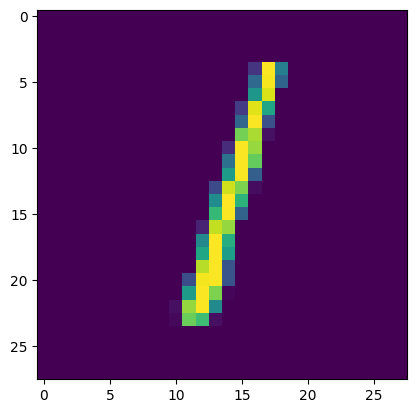

In [67]:
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))
model.load_weights('cnn.weights.h5')

predict = model.predict(X_test[1:2])
print(predict)
print(np.argmax(predict),np.argmax(y_test[1]))
plt.imshow(X_test[1:2].reshape(28,28))
plt.show()

Bài tập

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Kích thước tập huấn luyện: (50000, 32, 32, 3)
Kích thước tập kiểm tra: (10000, 32, 32, 3)


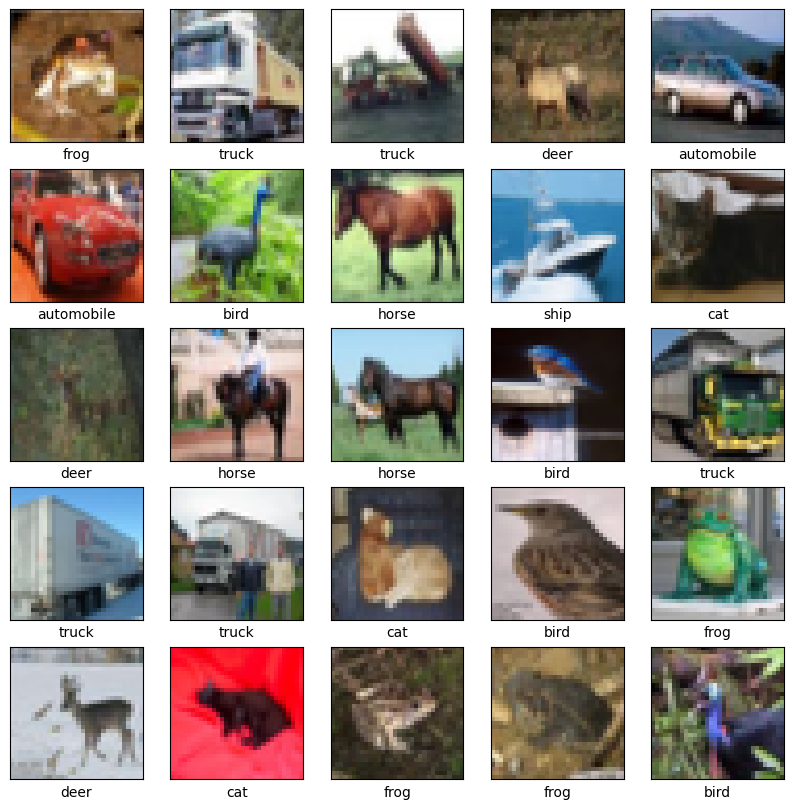

In [3]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

# Tải bộ dữ liệu CIFAR-10 từ thư viện tensorflow
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Chuẩn hóa các giá trị pixel về khoảng từ 0 đến 1
train_images, test_images = train_images / 255.0, test_images / 255.0

# Định nghĩa danh sách các nhãn tương ứng với bảng dữ liệu bài tập
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Kiểm tra kích thước dữ liệu
print(f"Kích thước tập huấn luyện: {train_images.shape}")
print(f"Kích thước tập kiểm tra: {test_images.shape}")

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    # train_labels hiện tại là mảng 2 chiều, cần dùng [i][0] để lấy giá trị nhãn phẳng
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()



In [4]:
model = models.Sequential()

# Khối tích chập 1
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))

# Khối tích chập 2
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# Khối tích chập 3
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

# Lớp phẳng và các lớp ẩn phân loại
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10)) # 10 nút tương ứng với 10 nhãn phân loại từ 0-9

# Hiển thị cấu trúc mạng mạng CNN đã thiết lập
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Biên dịch mô hình
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# Tiến hành huấn luyện trong 10 epochs
history = model.fit(train_images, train_labels, epochs=10,
                    validation_data=(test_images, test_labels))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 51ms/step - accuracy: 0.4468 - loss: 1.5138 - val_accuracy: 0.5415 - val_loss: 1.2631
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 44ms/step - accuracy: 0.5926 - loss: 1.1453 - val_accuracy: 0.6225 - val_loss: 1.0675
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 46ms/step - accuracy: 0.6490 - loss: 0.9968 - val_accuracy: 0.6497 - val_loss: 0.9935
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 44ms/step - accuracy: 0.6888 - loss: 0.8932 - val_accuracy: 0.6771 - val_loss: 0.9278
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 44ms/step - accuracy: 0.7097 - loss: 0.8296 - val_accuracy: 0.6923 - val_loss: 0.9011
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 44ms/step - accuracy: 0.7293 - loss: 0.7684 - val_accuracy: 0.7012 - val_loss: 0.8730
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 46ms/step - accuracy: 0.7488 - loss: 0.7164 - val_accuracy: 0.7121 - val_loss: 0.8448
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 45ms/step - accuracy: 0.7650 -

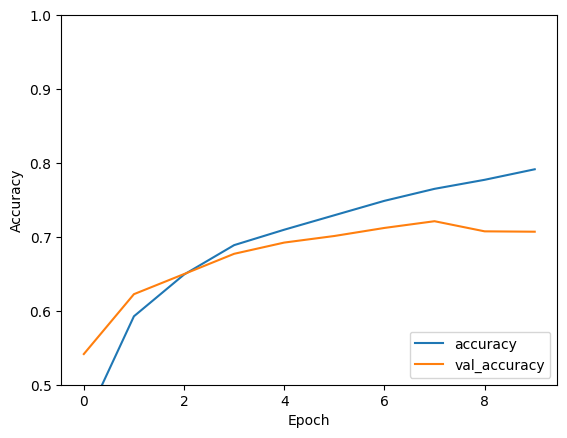

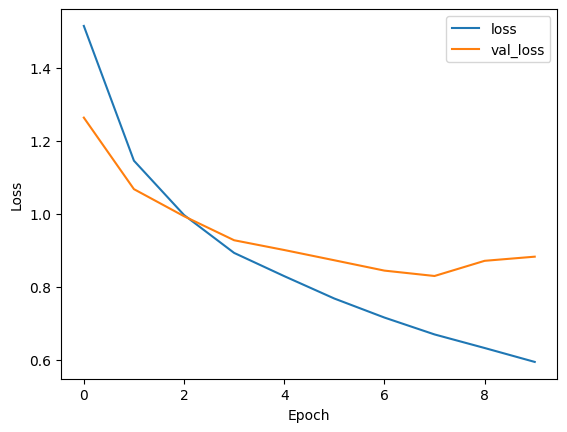

313/313 - 4s - 14ms/step - accuracy: 0.7070 - loss: 0.8829

Độ chính xác trên tập kiểm tra (Test Accuracy): 70.70%


In [7]:
# Vẽ đồ thị kết quả
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
plt.show()

plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label = 'val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()
# Đánh giá trên tập dữ liệu kiểm tra (Test dataset)
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)
print(f"\nĐộ chính xác trên tập kiểm tra (Test Accuracy): {test_acc * 100:.2f}%")



313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


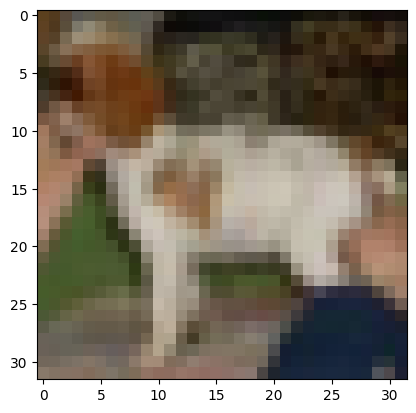

Nhãn mô hình dự đoán: bird (Mã: 2)
Nhãn thực tế của ảnh: dog (Mã: 5)


In [13]:

probability_model = tf.keras.Sequential([model, tf.keras.layers.Softmax()])
predictions = probability_model.predict(test_images)


img_index = 12
plt.figure()
plt.imshow(test_images[img_index])
plt.grid(False)
plt.show()

predicted_label = np.argmax(predictions[img_index])
true_label = test_labels[img_index][0]

print(f"Nhãn mô hình dự đoán: {class_names[predicted_label]} (Mã: {predicted_label})")
print(f"Nhãn thực tế của ảnh: {class_names[true_label]} (Mã: {true_label})")